# Import package

In [1]:
import matplotlib.pyplot as plt
from C_SingleHighQ import SingleHighQ


# import data

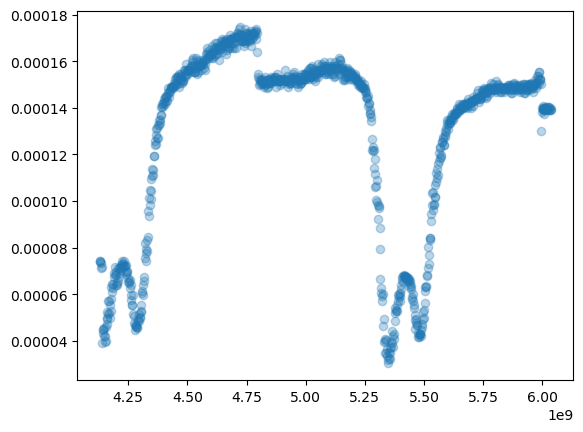

In [2]:

### another example usage for Fine Scan measurement
Q = SingleHighQ()
Fig_T = plt.figure()
ax_T = Fig_T.add_subplot(111)
# T_corrected = Q.load_data_singleQ(file_name=r'C:\Users\yijun.yang\OneDrive\1A_PostDoc\SiN\202509_2509SiN700A_Multipassage\mesurement\Laser fine tunning\D80\RR0.4.txt',
#                                   model='FineScan',
#                                   )
FolderName = r'C:\Users\yijun.yang\OneDrive\1A_PostDoc\SiN\202511SiN700A_4P_HighQ-PC\FineScan Measurement\D80'
FolderName = r'/Users/yangyijun/Library/CloudStorage/OneDrive-Personal/1A_PostDoc/SiN/202511SiN700A_4P_HighQ-PC/FineScan Measurement/D75'
FolderName = r'C:\Users\yijun.yang\OneDrive\1A_PostDoc\SiN\202511SiN700A_4P_HighQ-PC\FineScan Measurement\EdgeCoupler\D85'
# FolderName = r'/Users/yangyijun/Library/CloudStorage/OneDrive-Personal/1A_PostDoc/SiN/202511SiN700A_4P_HighQ-PC/FineScan Measurement/EdgeCoupler/D85'


FileName = r'RRW1.1G0.5L1522.856F10mHzA2V.txt'
# RRW1.1G0.5L1570.515F510mHzA2V
from F_GetConfig import F_GetConfig
config = F_GetConfig(FileName = FileName)
ScanConfig = {'Vpp_V':config['amplitude_V']*2,'Freq_Hz':config['freq_mHz']*1e-3,'Tunning_Hz_V':300*1e6}
# ScanConfig = {'Vpp_V':config['amplitude_V']*2,'Freq_Hz':10*1e-3,'Tunning_Hz_V':300*1e6}
from os.path import join
file_name=join(FolderName,FileName)




T_corrected = Q.load_data_singleQ(file_name=file_name,
                                    model='FineScan',ScanParams=ScanConfig)
ax_T.plot(T_corrected['nu_Hz'], T_corrected['T_linear'],'o',label='resonance',alpha=0.3)






# Singlet fit


FIT QUALITY REPORT - Single Lorentzian

Overall Fit Quality: Poor
Suitable for Analysis: NO

------------------------------------------------------------
Goodness-of-Fit Metrics:
------------------------------------------------------------
  R² (coefficient of determination): 0.846757
  Adjusted R²:                        0.846450
  RMSE (Root Mean Square Error):      8.132048e-02
  Normalized RMSE:                    8.257%
  χ² (Chi-squared):                   6.626247e+00
  Reduced χ²:                         0.006633
  Residual Std Dev:                   7.797993e-02
  Max Absolute Residual:              3.456040e-01

------------------------------------------------------------
Fitted Parameters:
------------------------------------------------------------
  Amplitude       = 7.447495e-01 ± 1.291185e-02 (1.73%)
  FWHM (Hz)       = 1.948500e+08 ± 4.791690e+06 (2.46%)
  Resonance (Hz)  = 5.420000e+09 ± 1.688216e+06 (0.03%)

-----------------------------------------------------------

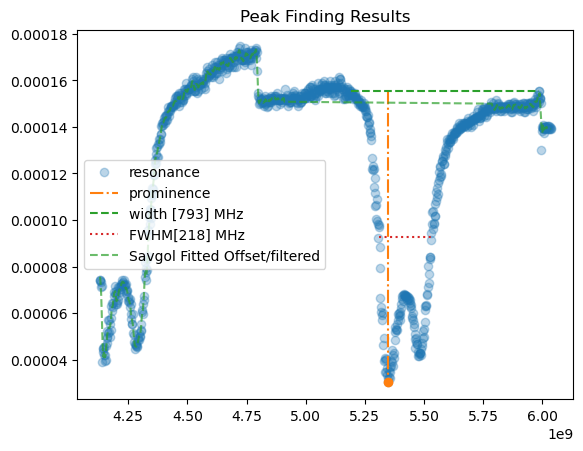

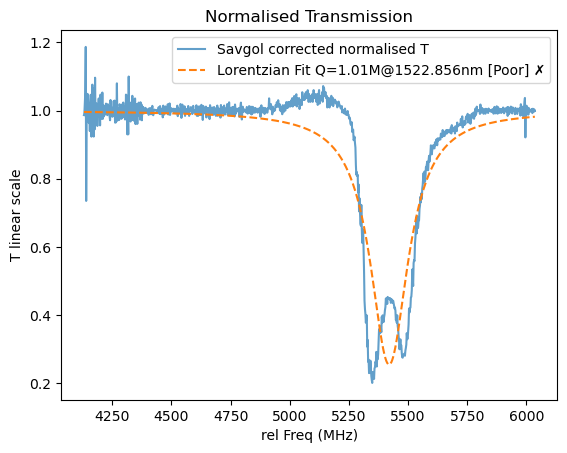

In [3]:
Fig_T_normalised = plt.figure()
ax_T_normalised = Fig_T_normalised.add_subplot(111)

param_find_peaks = {'distance':400,# in number of points
                    'prominence':0.0001,# need to be adjusted according to the actual data
                    'width':5,# in number of points
                    'rel_height':1,# don't change this one
                    }
param_rel = {'Rel_FWHM':0.2,
                'Rel_A':0.2,
                'Rel_Peak':0.2,
                'factor_remove_points':1.1,# factor to multiply the width to get the points to remove for Savgol filtering
    }
from F_FindPeaks import F_SelectPeaks
# param_find_peaks = F_SelectPeaks(T_corrected['T_linear'].values, param_find_peaks, num_peaks=5)
T_normalised = Q.PL_FitResonance(
    T_corrected=T_corrected,
    center_wl_nm=config['wavelength_nm'],
    ax_T_normalised=ax_T_normalised,
    ax_T=ax_T,
    param_rel=param_rel,
    **param_find_peaks)

# plt.show()
# plt.figure(Fig_T.number)
# plt.show()

# Fig_T.canvas.draw_idle()
display(Fig_T)            # shows updated ax_T
# display(Fig_T_normalised)

# Doublet fit


FIT QUALITY REPORT - Double Lorentzian

Overall Fit Quality: Fair
Suitable for Analysis: NO

------------------------------------------------------------
Goodness-of-Fit Metrics:
------------------------------------------------------------
  R² (coefficient of determination): 0.963983
  Adjusted R²:                        0.963803
  RMSE (Root Mean Square Error):      3.942398e-02
  Normalized RMSE:                    4.003%
  χ² (Chi-squared):                   1.557358e+00
  Reduced χ²:                         0.001564
  Residual Std Dev:                   3.679452e-02
  Max Absolute Residual:              2.630987e-01

------------------------------------------------------------
Fitted Parameters:
------------------------------------------------------------
  Amplitude       = 7.300661e-01 ± 1.057648e-02 (1.45%)
  FWHM (Hz)       = 7.379644e+07 ± 1.939569e+06 (2.63%)
  Resonance (Hz)  = 5.353070e+09 ± 5.737061e+05 (0.01%)

-----------------------------------------------------------

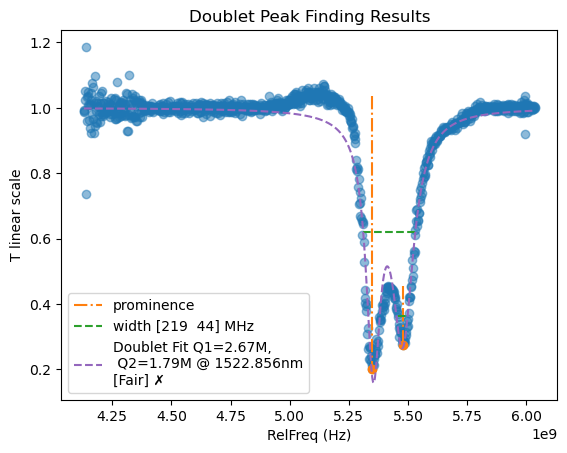

In [5]:
Fig_Doublet = plt.figure()
ax_Doublet = Fig_Doublet.add_subplot(111)
param_find_DoubletResonance = {'distance':2,
                            'prominence':0.11,
                            'width':4,
                            'rel_height':0.5,
                            } # don't add random stuff here, only the parameters suitable for scipy.find_peaks

param_rel_Doublet = {'Rel_A1':0.99,
                        'Rel_A2':0.99,
                    #  'Rel_FWHM1':0.8,
                    #  'Rel_FWHM2':0.8,
                        'Rel_Peak1': 0.01,
                        'Rel_Peak2':0.01,
                        '1st peak':0, # multiple peaks found, choose which the one as the first peak
                        '2nd peak':1,}# multiple peaks found, choose which the one as the second peak

opt_Doublet, pcov_Doublet, f_func_DoubleLorentzian = Q.Q_FitDoubletResonance(T_normalised,
                                                                            center_wl_nm=config['wavelength_nm'],
                                                                            param_find_DoubletResonance=param_find_DoubletResonance,
                                                                            param_rel_Doublet=param_rel_Doublet,
                                                                            ax_Doublet=ax_Doublet)




plt.show()